In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf 

In [2]:
# an alternative to panda's insert(args) since it throws an error if the column already exists
# same logic but instead of df.insert, we use insert_or_replace(df, args)
def insert_or_replace(df, position, name, values):
    if name in df.columns:
        df.drop(columns=name, inplace=True)
    df.insert(position, name, values)

# gives the position to insert columns after a specified column
from typing import cast

# for some reason pylance never lets me use .get_loc() + 1
def nextpos(df, col:str)->int:
    pos = cast(int, df.columns.get_loc(col))
    return pos + 1

# if i ever need to swap cols
def swapcolumns(df, col1:str, col2:str):
    columns = list(df.columns)
    new = columns.index(col1) 
    old = columns.index(col2)

    columns[new], columns[old] = columns[old], columns[new]

    df = df[columns]
    return df


In [42]:
panel = pd.read_parquet("../data/pipeline/panel.parquet")

### Mincer-Zarnowitz regression

Never ended up using this. Thought it was a pretty cool idea but it was pretty much entirely focused on calibration, and I couldn't see how I can tie this into the information story the paper tries to tell.

In [12]:
def mincer_zarnowitz(df_og,
                    time_labels = [
                    "0-1 day",
                    "1-2 days",
                    "2-4 days",
                    "4-7 days",
                    "1-2 weeks",
                    "2-4 weeks",
                    "1-2 months",
                    "2-4 months",
                    ">4 months"]):
    
    # yes_outcomes was bool before which isnt accepted
    # so we'll make it 0/1
    df = df_og.copy()
    df["yes_outcomes"] = df["yes_outcomes"].astype(int)

    final_results = []
    final_tests = []

    # run a regression for every ttr bin given
    for time in time_labels:
        df_bin = df.loc[df.ttr_bin == time]

        # skip bins with no data in this cohort, rather than erroring
        # important for the cohorts
        if df_bin.empty:
            continue  

        # we only look at the last observation for each market
        # so each market contributes only 1 observation to the regression
        df_bin = df_bin.groupby("market_id").last()

        model = smf.ols('yes_outcomes ~ p', data = df_bin)
        market_ids = df_bin.index.get_level_values("market_id")

        results = model.fit(cov_type = "HC1")

        intercept = results.params["Intercept"]
        intercept_p = results.pvalues["Intercept"]

        slope = results.params["p"]
        slope_p = results.pvalues["p"]

        num_markets = market_ids.nunique()

        final = [intercept, intercept_p, slope, slope_p, num_markets]
        final_results.append(final)


        # testing null: intercept = 0 and slope = 1
        wald = results.wald_test("Intercept = 0, p = 1", use_f=True, scalar = True)
        F_stat = wald.statistic
        p_value = wald.pvalue
        df_num = wald.df_num
        df_denom = wald.df_denom

        tests = [F_stat, df_num, df_denom, p_value]
        final_tests.append(tests)

    # return a df instead of a 2d list
    results_table = pd.DataFrame(
    final_results,
    columns=[
        "Intercept",
        "Intercept p-value",
        "Slope",
        "Slope p-value",
        "Number of markets"
    ],
    index=time_labels[:len(final_results)]
    )

    tests_table = pd.DataFrame(
    final_tests,
    columns=[
        "F statistic",
        "df num",
        "df denom",
        "p-value",
    ],
    index=time_labels[:len(final_tests)]
    )   

    return results_table, tests_table

In [ ]:
final_results, final_tests = mincer_zarnowitz(panel)

In [ ]:
final_results

In [ ]:
final_tests

In [ ]:
# creates a subset of the data that can be put into compute_decay_curve 
def create_cohort(data, target_bin, time_edges = [0, 24, 48, 96, 168, 336, 720, 1440, 2880, np.inf], 
                time_labels = [
                "0-1 day",
                "1-2 days",
                "2-4 days",
                "4-7 days",
                "1-2 weeks",
                "2-4 weeks",
                "1-2 months",
                "2-4 months",
                ">4 months"]):
    # for each market, find the furthest point it was ever tracked
    max_ttr_per_market = data.groupby("market_id")["time_to_resolution"].max()

    # same time-binning as before
    market_lifespan_bin = pd.cut(
    max_ttr_per_market,
    bins=time_edges,
    labels=time_labels,
    include_lowest=True,
    ordered=True
    )

    # filter to find the bin that matches the target and select those from the input data
    matching_ids = market_lifespan_bin[market_lifespan_bin == target_bin].index
    cohort = data[data.index.get_level_values("market_id").isin(matching_ids)].copy()

    print(f"Cohort size: {cohort.index.get_level_values('market_id').nunique()} markets")
    print(f"Original sample: {data.index.get_level_values('market_id').nunique()} markets")

    return cohort

In [13]:
cohort_panel = create_cohort(panel, ">4 months") # to control for market size
cohort_results, cohort_tests = mincer_zarnowitz(cohort_panel)

Cohort size: 4780 markets
Original sample: 49661 markets


In [14]:
cohort_results

,Intercept,Intercept p-value,Slope,Slope p-value,Number of markets
0-1 day,-0.001169,2.159701e-14,1.003639,0.0,4779
1-2 days,-0.005213,1.586610e-04,1.035587,0.0,4778
2-4 days,-0.005132,3.791158e-04,1.047203,0.0,4778
4-7 days,-0.004343,6.343980e-03,1.054648,0.0,4778
1-2 weeks,-0.004518,1.048115e-02,1.054541,0.0,4779
2-4 weeks,-0.003818,4.591321e-02,1.052103,0.0,4780
1-2 months,-0.004772,3.403596e-02,1.054873,0.0,4780
2-4 months,-0.008333,1.605726e-03,1.039247,0.0,4780
>4 months,-0.016120,8.559455e-07,0.948991,0.0,4780


In [15]:
cohort_tests

,F statistic,df num,df denom,p-value
0-1 day,110.032273,2.0,4777.0,1.912555e-47
1-2 days,27.474795,2.0,4776.0,1.367628e-12
2-4 days,35.792750,2.0,4776.0,3.721782e-16
4-7 days,33.771767,2.0,4776.0,2.728049e-15
1-2 weeks,26.803520,2.0,4777.0,2.655887e-12
2-4 weeks,16.477034,2.0,4778.0,7.390591e-08
1-2 months,11.393072,2.0,4778.0,1.158278e-05
2-4 months,6.751416,2.0,4778.0,1.180410e-03
>4 months,22.350220,2.0,4778.0,2.180451e-10


In [ ]:
# same aggregation that we've been doing, but yes_rate, pred and n are now column names
df = panel.groupby("price_bins", observed=True).agg(
    yes_rate=("yes_outcomes", "mean"),
    pred=("p", "mean"),
    n=("p", "size"))

df.reset_index()

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.scatter(df["pred"], df["yes_rate"])
plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.show()

## Martingales

In [43]:
## construct the variables for a better martingale regression
panel["delta_p"] = panel.groupby("market_id", observed = True)["p"].diff() 
# gives us delta_pt-1
panel["delta_p_lagged"] = panel.groupby("market_id", observed = True)["delta_p"].shift(1)

# just using delta_pt-1 will give us a -ve serial correlation cause of
# bid ask bounce, which we also faced
# so we'll regress on more lagged p
panel["delta_p_lagged2"] = panel.groupby("market_id", observed = True)["delta_p"].shift(2)
panel["delta_p_lagged3"] = panel.groupby("market_id", observed = True)["delta_p"].shift(3)

# compute volatility over the past 24 hr rolling window
window = 24 
panel["volatility"] = (panel.groupby("market_id", observed = True)["delta_p_lagged"]
                       .rolling(window, min_periods=5)
                       .std()
                       # drops the extra index created
                       # just level = "market_id" throws an error cause we're grouping 
                       # by something thats already in the index, so we get market_id in the
                       # index twice, confusing the level = "market_id" argument
                       .reset_index(level=0,drop=True))

# if we ever want to regress on actual observed outcomes
panel["yes_outcomes_int"] = panel["yes_outcomes"].astype(int)

In [ ]:
# martingale
cols_needed = ["delta_p", "p", "time_to_resolution", "delta_p_lagged", "volatility"]
panel_reg = panel[cols_needed].dropna().copy()

model = smf.ols("delta_p ~ p + scale(time_to_resolution) + scale(delta_p_lagged) + scale(volatility)", data = panel_reg)
market_ids = panel_reg.index.get_level_values("market_id")

# method = qr alleviates memory troubles
results = model.fit(method="qr", cov_type="cluster", cov_kwds={"groups": market_ids})
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2096.
Date:                Fri, 24 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:03:10   Log-Likelihood:             1.1154e+08
No. Observations:            43001560   AIC:                        -2.231e+08
Df Residuals:                43001555   BIC:                        -2.231e+08
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [22]:
wald = results.wald_test("Intercept = 0, p = 0, scale(time_to_resolution) = 0, scale(delta_p_lagged) = 0, scale(volatility) = 0", use_f=True, scalar = True)
F_stat = wald.statistic
p_value = wald.pvalue
df_num = wald.df_num
df_denom = wald.df_denom

print(f"""F_stat: {F_stat}
p_value: {p_value}
df_num: {df_num}
df_denom: {df_denom}""")

F_stat: 2315.463783261146
p_value: 0.0
df_num: 5.0
df_denom: 49559


In [25]:
# martingale w many lags
cols_needed = ["delta_p", "p", "time_to_resolution", "delta_p_lagged", "delta_p_lagged2", "delta_p_lagged3", "volatility"]
panel_reg = panel[cols_needed].dropna().copy()

model = smf.ols("delta_p ~ p + scale(time_to_resolution) + scale(delta_p_lagged) + scale(delta_p_lagged2) + scale(delta_p_lagged3) + scale(volatility)", data = panel_reg)
market_ids = panel_reg.index.get_level_values("market_id")

# method = qr alleviates memory troubles
results = model.fit(method="qr", cov_type="cluster", cov_kwds={"groups": market_ids})
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     1387.
Date:                Fri, 24 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:28:34   Log-Likelihood:             1.1160e+08
No. Observations:            43001560   AIC:                        -2.232e+08
Df Residuals:                43001553   BIC:                        -2.232e+08
Df Model:                           6                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [26]:
wald = results.wald_test("Intercept = 0, p = 0, scale(time_to_resolution) = 0, scale(delta_p_lagged) = 0, scale(volatility) = 0", use_f=True, scalar = True)
F_stat = wald.statistic
p_value = wald.pvalue
df_num = wald.df_num
df_denom = wald.df_denom

print(f"""F_stat: {F_stat}
p_value: {p_value}
df_num: {df_num}
df_denom: {df_denom}""")

F_stat: 2168.8694188231957
p_value: 0.0
df_num: 5.0
df_denom: 49559


In [27]:
# autocorrelation
cols_needed = ["delta_p", "delta_p_lagged", "delta_p_lagged2", "delta_p_lagged3"]
panel_reg = panel[cols_needed].dropna().copy()

model = smf.ols("delta_p ~ delta_p_lagged + delta_p_lagged2 + delta_p_lagged3", data = panel_reg)
market_ids = panel_reg.index.get_level_values("market_id")

# method = qr alleviates memory troubles
results = model.fit(method="qr", cov_type="cluster", cov_kwds={"groups": market_ids})
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1746.
Date:                Fri, 24 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:29:46   Log-Likelihood:             1.1124e+08
No. Observations:            43100752   AIC:                        -2.225e+08
Df Residuals:                43100748   BIC:                        -2.225e+08
Df Model:                           3                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -6.715e-05   2.48e-06    -

In [29]:
wald = results.wald_test("Intercept = 0, delta_p_lagged = 0, delta_p_lagged2 = 0, delta_p_lagged3=0", use_f=True, scalar = True)
F_stat = wald.statistic
p_value = wald.pvalue
df_num = wald.df_num
df_denom = wald.df_denom

print(f"""F_stat: {F_stat}
p_value: {p_value}
df_num: {df_num}
df_denom: {df_denom}""")

F_stat: 1358.347459653207
p_value: 0.0
df_num: 4.0
df_denom: 49605


In [ ]:
cols_needed = ["delta_p", "p", "time_to_resolution", "delta_p_lagged", "volatility"]
panel_reg = panel[cols_needed].dropna().copy()

model = smf.ols("delta_p ~ scale(p) + scale(time_to_resolution) + scale(delta_p_lagged) + scale(volatility)", data = panel_reg)
market_ids = panel_reg.index.get_level_values("market_id")

# method = qr alleviates memory troubles
results = model.fit(method="qr", cov_type="cluster", cov_kwds={"groups": market_ids})
print(results.summary())

In [8]:
wald = results.wald_test("Intercept = 0, scale(p) = 0, scale(time_to_resolution) = 0, scale(delta_p_lagged) = 0, scale(volatility) = 0", use_f=True, scalar = True)
F_stat = wald.statistic
p_value = wald.pvalue
df_num = wald.df_num
df_denom = wald.df_denom

print([F_stat, p_value, df_num, df_denom])

[2315.4637832629815, np.float64(0.0), 5.0, 49559]


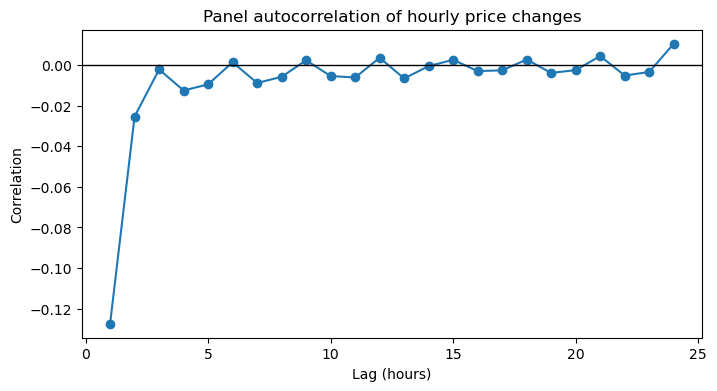

In [ ]:
max_lag = 24

# plot the autocorrelation function
acf = []

for lag in range(1, max_lag + 1):
    # corr between delta p and delta_p_lagged for all lag values from 1 to 24
    corr = panel["delta_p"].corr(panel.groupby("market_id", observed=True)["delta_p"].shift(lag))
    acf.append(corr)

plt.figure(figsize=(8,4))
plt.plot(range(1, max_lag + 1), acf, marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.title("Panel autocorrelation of hourly price changes")
plt.show()

In [34]:
print(panel.columns.tolist())

['token_id', 'p', 'price_bins', 'yes_outcomes', 'createdAt', 'closedTime', 'time_to_resolution', 'ttr_bin', 'negRisk', 'delta_p', 'delta_p_lagged', 'volatility', 'yes_outcomes_int', 'delta_p_lagged2', 'delta_p_lagged3']


In [44]:
print(panel.index.names)
print(panel.index.get_level_values("market_id").nunique())

['market_id', 't']
49661


In [46]:
import statsmodels.api as sm
results = []

count = 0
for market_id, df in panel.groupby(level = "market_id"):
    df = df.dropna(subset=[
        "delta_p",
        "delta_p_lagged",
        "delta_p_lagged2",
        "delta_p_lagged3"
    ])

    # Require a reasonable sample size
    if len(df) < 30:
        continue

    X = sm.add_constant(
        df[[
            "delta_p_lagged",
            "delta_p_lagged2",
            "delta_p_lagged3"
        ]]
    )

    y = df["delta_p"]

    try:
        model = sm.OLS(y, X).fit()

        results.append({
            "market_id": market_id,
            "beta1": model.params["delta_p_lagged"],
            "beta2": model.params["delta_p_lagged2"],
            "beta3": model.params["delta_p_lagged3"],
            "r2": model.rsquared,
            "n": len(df)
        })

    except Exception as e:
        print(f"{market_id}: {e}")
        break

betas = pd.DataFrame(results)

print(betas.describe())

betas.to_csv("market_specific_ar3_coefficients.csv", index=False)

c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\daniel\anaconda3\envs\quantecon\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/sel

              beta1         beta2         beta3            r2             n
count  47692.000000  47692.000000  47692.000000  47674.000000  47692.000000
mean      -0.088730     -0.294936     -0.021755      0.096874    902.962929
std        0.686430     44.785014      0.625377      0.128856   1471.534904
min      -28.979822  -9779.788213    -17.612948      0.000000     30.000000
25%       -0.213408     -0.152110     -0.073208      0.017867    165.000000
50%       -0.072911     -0.052978     -0.010108      0.049548    311.000000
75%        0.032403      0.008538      0.032358      0.121652    793.000000
max       98.885385     18.297048     71.968753      0.999898  14073.000000


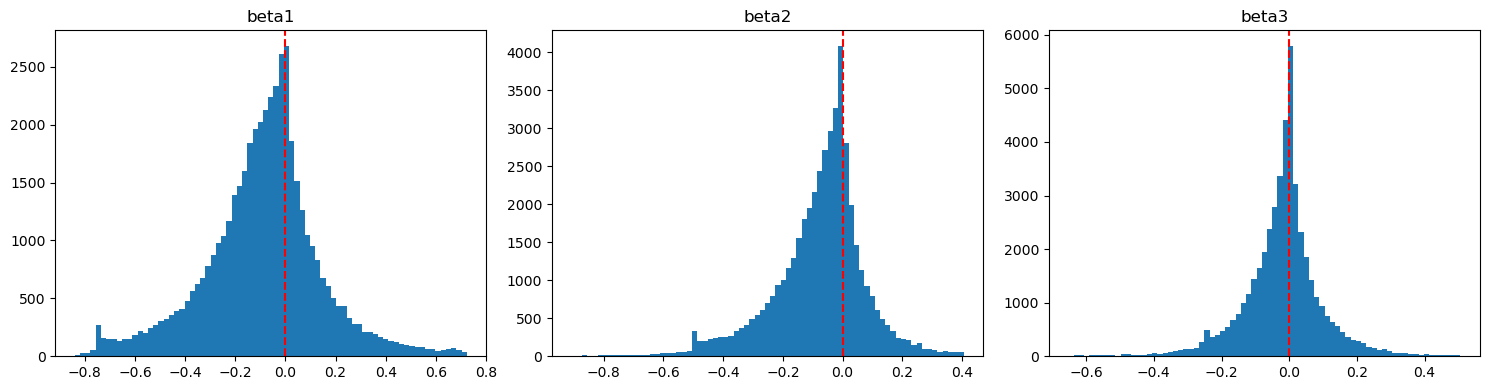

In [48]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

for ax, col in zip(axes, ["beta1","beta2","beta3"]):

    x = betas[col]

    lo = x.quantile(0.01)
    hi = x.quantile(0.99)

    x = x[(x >= lo) & (x <= hi)]

    ax.hist(x, bins=75)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(col)

plt.tight_layout()